In [1]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch


words = open('names.txt', 'r').read().splitlines()

sorted_chars = sorted(list(set(''.join(words))))
enumerated = enumerate(sorted_chars)
char_to_idx = {char: idx + 1 for idx, char in enumerated}
char_to_idx['.'] = 0
idx_to_char = {idx: char for char, idx in char_to_idx.items()}

print(char_to_idx)
print(idx_to_char)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [10]:
a = torch.randn(1,2,3,4)
b = a.transpose(1, 2)

print(b.shape)
c = a.view(1,3,2,4)

print(c.shape)

print(torch.equal(b, c))

print(c.storage())

print(b.storage())



torch.Size([1, 3, 2, 4])
torch.Size([1, 3, 2, 4])
False
 0.24759283661842346
 -0.03855631873011589
 1.4059092998504639
 -0.32018744945526123
 -2.2889223098754883
 1.0190309286117554
 -0.6074780225753784
 -1.8917616605758667
 0.7793946266174316
 -0.848656415939331
 0.8221848011016846
 1.4453797340393066
 0.2936969995498657
 -1.0335625410079956
 0.041790250688791275
 -0.2581837475299835
 1.4189108610153198
 0.1883464902639389
 -0.487407922744751
 0.3503131568431854
 0.17490805685520172
 -0.8998402953147888
 -0.9976682066917419
 -0.27966466546058655
[torch.storage.TypedStorage(dtype=torch.float32, device=cpu) of size 24]
 0.24759283661842346
 -0.03855631873011589
 1.4059092998504639
 -0.32018744945526123
 -2.2889223098754883
 1.0190309286117554
 -0.6074780225753784
 -1.8917616605758667
 0.7793946266174316
 -0.848656415939331
 0.8221848011016846
 1.4453797340393066
 0.2936969995498657
 -1.0335625410079956
 0.041790250688791275
 -0.2581837475299835
 1.4189108610153198
 0.1883464902639389
 -

/tmp/ipykernel_1249/3847189042.py:11: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  print(c.storage())


In [37]:
ix = torch.randint(0, X.shape[0], (32,))
print(ix.shape)
print(ix)


print(X.shape[0])

torch.Size([32])
tensor([ 54568,  84653,  21483, 216712, 198160, 124331, 173086,  10923,  17920,
        191247,  38210,  42040,  10613, 178329, 213214,   4759, 180061, 207514,
        204729, 178866, 125859, 152392, 138857, 106135, 146009,  26909,   3021,
        170548, 198599,  76490,  20627, 215523])
228146


In [70]:
import random
def construct_dataset(words, block_size):
  X, Y = [], []
  for word in words:
    context = [0] * block_size
    for ch in word + '.':
      X.append(context)
      idx = char_to_idx[ch]
      Y.append(idx)
      context = context[1:] + [idx]
  return torch.tensor(X), torch.tensor(Y)

random.seed(42)
random.shuffle(words)
num_words = len(words)
training_size = int(0.8 * num_words)
validation_size = int(0.1 * num_words)
test_size = num_words - training_size - validation_size
block_size = 5

X_train, Y_train = construct_dataset(words[:training_size], block_size)
X_val, Y_val = construct_dataset(words[training_size:training_size + validation_size], block_size)
X_test, Y_test = construct_dataset(words[training_size + validation_size:], block_size)

print(X_train.shape, Y_train.shape)
print(X_val.shape, Y_val.shape)
print(X_test.shape, Y_test.shape)

torch.Size([182691, 5]) torch.Size([182691])
torch.Size([22793, 5]) torch.Size([22793])
torch.Size([22662, 5]) torch.Size([22662])


In [63]:
### Get starting loss with unifirm probabilities
print(Y_train.shape)
val = 1.0 / 27
arr = val * torch.ones(Y_train.size())
starting_loss = -(arr.log()).mean()
print(val, starting_loss)


torch.Size([182484])
0.037037037037037035 tensor(3.2958)


In [82]:
g = torch.Generator().manual_seed(2147483647)
embedding_dimension = 5

#Random initialisation
C = torch.randn((27, embedding_dimension), generator=g)
W1 = torch.randn((embedding_dimension * block_size, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)

mat_dimension = block_size * embedding_dimension
invisible_layer_dimension = 300

## Uniform initialisation
# C = torch.ones((27, embedding_dimension))
# w1_weights = 1.0 / (mat_dimension * invisible_layer_dimension)
# w1_bias = 1.0 / (invisible_layer_dimension)
# W1 = w1_weights * torch.ones(mat_dimension, invisible_layer_dimension)
# b1 = w1_bias * torch.ones(invisible_layer_dimension)
# w2_weights = 1.0 / (invisible_layer_dimension * 27)
# w2_bias = (1.0 / 27)
# W2 = w2_weights * torch.ones(invisible_layer_dimension, 27)
# b2 = w2_bias * torch.ones(27)


embeddings = C[X_train]
h = torch.tanh(embeddings.view(-1, mat_dimension) @ W1 + b1)

parameters = [C, W1, b1, W2, b2]
num_params = [sum(p.nelement() for p in parameters)]
print(num_params)
for p in parameters:
  p.requires_grad = True

print(W1.shape, b1.shape, W2.shape, b2.shape)

[5462]
torch.Size([25, 100]) torch.Size([100]) torch.Size([100, 27]) torch.Size([27])


In [89]:
sample_size = 50
step = []
loss_values = []
for i in range(200000):
  ## sample random entries from dataset

  ix = torch.randint(0, X_train.shape[0], (sample_size,))

  emb = C[X_train[ix]]
  h = torch.tanh(emb.view(-1, mat_dimension) @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Y_train[ix])
  print(loss.item())

  for p in parameters:
    p.grad = None
  loss.backward()

  learning_rate = 0.1 if i < 100000 else 0.01

  for p in parameters:
    p.data += -learning_rate * p.grad

  step.append(i)
  loss_values.append(loss.log10().item())

# plt.plot(step, loss_values)
# plt.show()

Streaming output truncated to the last 5000 lines.
2.067857265472412
2.2232460975646973
2.1847143173217773
1.983911395072937
1.8790682554244995
2.2689287662506104
2.3694849014282227
1.9638242721557617
1.9591106176376343
2.2409026622772217
2.0552549362182617
1.9147411584854126
2.2032787799835205
2.2543745040893555
2.1088063716888428
2.1276581287384033
2.061429023742676
2.2042696475982666
2.205965042114258
2.160055160522461
1.9457687139511108
2.004756212234497
2.4103994369506836
1.9418739080429077
2.178574323654175
2.20121693611145
1.969316840171814
1.848885178565979
2.0932352542877197
2.0785365104675293
1.8518948554992676
2.0071327686309814
2.314879894256592
2.2940993309020996
2.282388925552368
2.0827672481536865
2.2590856552124023
2.2835450172424316
1.8155766725540161
2.0945260524749756
2.1535723209381104
2.5032761096954346
2.341155529022217
2.3058669567108154
1.833691120147705
2.3031160831451416
2.1879708766937256
2.2859199047088623
2.1507346630096436
2.254272222518921
2.1260049343109

In [93]:
emb = C[X_val]
h = torch.tanh(emb.view(-1, mat_dimension) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_val)
print(loss.item())

2.1278512477874756


In [92]:
emb = C[X_train]
h = torch.tanh(emb.view(-1, mat_dimension) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_train)
print(loss.item())

2.085811138153076


In [94]:
emb = C[X_test]
h = torch.tanh(emb.view(-1, mat_dimension) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_test)
print(loss.item())

2.1436359882354736


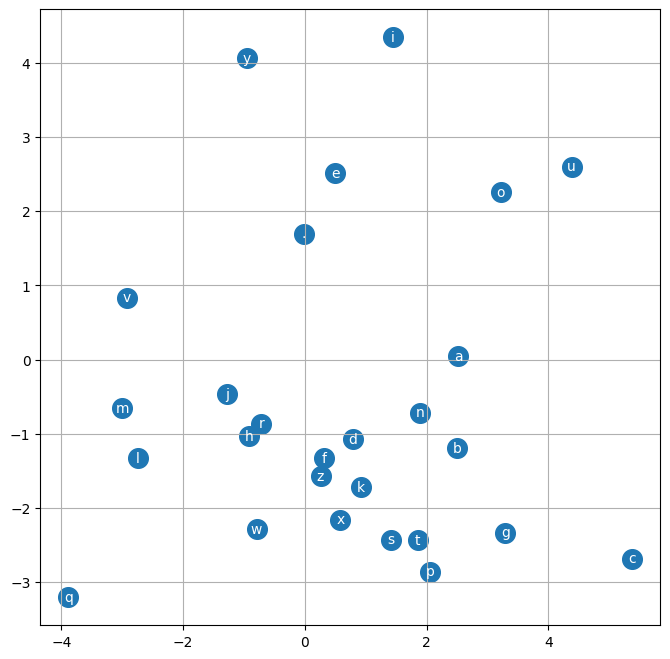

In [87]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), idx_to_char[i], ha="center", va="center", color='white')
plt.grid('minor')

In [97]:
g = torch.Generator().manual_seed(2147483647)
for i in range(10):
  context = [0] * block_size
  word_idx = []
  while True:
    embedding = C[torch.tensor([context])]
    h = torch.tanh(embedding.view(1, -1) @ W1 + b1)
    logits = h @ W2 + b2
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
    word_idx.append(ix)
    context = context[1:] + [ix]
    if ix == 0:
      break
  print(''.join(idx_to_char[i] for i in word_idx))

dexzline.
liussice.
kayder.
maimi.
tainella.
kama.
da.
samiyah.
javer.
gotai.
